<a href="https://colab.research.google.com/github/xKDR/India-Built-and-Lit/blob/main/building_volume.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building volume — reproducible pipeline

Computes annual **built-up volume** for every Indian district from the
Google Open Buildings 2.5D Temporal dataset, entirely inside Google Earth
Engine. Results come back with `getInfo()` — no Drive, no export tasks.

This notebook is **pure Python, single kernel** — run it top-to-bottom on
Google Colab (or locally). The district boundaries are fetched from GitHub,
so nothing else is needed.

**Output:** `bv_annual.csv` — one row per (district, year).


## 1 · Setup

In [1]:
# Colab ships earthengine-api; this just makes sure it's current.
!pip install -q -U earthengine-api

import ee

# Opens an auth pop-up on first run.
ee.Authenticate()

PROJECT = "gee-ntl-470405"          # <-- your GEE Cloud project id
ee.Initialize(project=PROJECT)
print("Earth Engine ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.6/479.6 kB 16.3 MB/s eta 0:00:00
Earth Engine ready.


## 2 · Parameters

`SCALE_M` is the **resampling knob**. Open Buildings is ~4 m native; reducing
at 100 m is far faster and, summed over a whole district, gives essentially
the same total. Lower it (e.g. 30 m) for a finer, slower run.


In [2]:
YEARS        = range(2016, 2024)      # Open Buildings 2.5D Temporal: 2016-2023
SCALE_M      = 100                    # reduction scale in metres (resampling knob)
BOUNDARY_URL = "https://raw.githubusercontent.com/xKDR/India-Built-and-Lit/main/data/boundaries/districts_simplified.geojson"
OUT_CSV      = "bv_annual.csv"
COLLECTION   = "GOOGLE/Research/open-buildings-temporal/v1"
ID_COLUMNS   = ["pc11_s_id", "pc11_d_id", "d_name"]

## 3 · Districts → `ee.FeatureCollection`

The simplified SHRUG district polygons are fetched from GitHub and loaded
inline — no GEE asset upload, no local file.


In [3]:
import json, urllib.request

with urllib.request.urlopen(BOUNDARY_URL) as resp:
    gj = json.load(resp)

feats = [
    ee.Feature(
        ee.Geometry(ft["geometry"], proj="EPSG:4326", geodesic=False),
        {k: ft["properties"].get(k) for k in ID_COLUMNS},
    )
    for ft in gj["features"]
]
districts = ee.FeatureCollection(feats)
print(districts.size().getInfo(), "districts loaded")

641 districts loaded


## 4 · Built-up volume per district per year

`volume = sum(building_height x pixel_area)`. The `building_height` band is 0
on non-building pixels, so the integral over a district polygon picks up only
the built-up area. `footprint_m2` is the area of pixels carrying any building.

`reduceRegions` over all 641 districts at once overruns GEE's interactive
compute budget ("Computation timed out"). So we reduce in **chunks** and pull
each with `getInfo()`; `reduce_chunk` **auto-splits** any chunk that still
times out, down to single districts — heavy districts end up in tiny batches.


In [4]:
import pandas as pd


def year_image(year):
    img = (ee.ImageCollection(COLLECTION)
           .filterDate(f"{year}-01-01", f"{year + 1}-01-01")
           .mosaic())
    px = ee.Image.pixelArea()
    h  = img.select("building_height")
    volume    = h.multiply(px).rename("volume_m3")
    footprint = px.multiply(h.gt(0)).rename("footprint_m2")
    return volume.addBands(footprint)


def reduce_chunk(img, chunk):
    """getInfo() a chunk of districts; on a compute timeout, split the chunk
    in half and recurse so heavy districts land in smaller batches."""
    try:
        fc = (img.reduceRegions(collection=ee.FeatureCollection(chunk),
                                reducer=ee.Reducer.sum(),
                                scale=SCALE_M, tileScale=16)
                 .select(ID_COLUMNS + ["volume_m3", "footprint_m2"],
                         retainGeometry=False))
        return fc.getInfo()["features"]
    except ee.ee_exception.EEException as e:
        if len(chunk) == 1 or "timed out" not in str(e).lower():
            raise
        mid = len(chunk) // 2
        return reduce_chunk(img, chunk[:mid]) + reduce_chunk(img, chunk[mid:])


CHUNK = 50          # districts per getInfo() call; auto-splits on timeout

frames = []
for year in YEARS:
    img = year_image(year)
    recs = []
    for start in range(0, len(feats), CHUNK):
        recs += reduce_chunk(img, feats[start:start + CHUNK])
    part = pd.DataFrame([r["properties"] for r in recs])
    part["year"] = year
    frames.append(part)
    print(f"  {year}: {len(part)} districts")

  2016: 641 districts
  2017: 641 districts
  2018: 641 districts
  2019: 641 districts
  2020: 641 districts
  2021: 641 districts
  2022: 641 districts


  2023: 641 districts


## 5 · Assemble → `bv_annual.csv`

In [5]:
df = pd.concat(frames, ignore_index=True)
df = df[df.footprint_m2 > 0].copy()
df["year"] = df["year"].astype(int)
df["mean_height_m"] = df.volume_m3 / df.footprint_m2
df = df[ID_COLUMNS + ["year", "footprint_m2", "volume_m3", "mean_height_m"]]
df = df.sort_values(["pc11_s_id", "pc11_d_id", "year"])
df.to_csv(OUT_CSV, index=False)
print(f"wrote {len(df)} rows -> {OUT_CSV}")
df.head()

wrote 5128 rows -> bv_annual.csv


,pc11_s_id,pc11_d_id,d_name,year,footprint_m2,volume_m3,mean_height_m
640,01,000,None,2016,2.276471e+09,1.912540e+09,0.840134
1281,01,000,None,2017,2.414304e+09,2.236454e+09,0.926335
1922,01,000,None,2018,1.864460e+09,1.124317e+09,0.603026
2563,01,000,None,2019,1.911426e+09,1.368818e+09,0.716124
3204,01,000,None,2020,1.979301e+09,1.461776e+09,0.738531


## 6 · Plot — national built-up volume by year

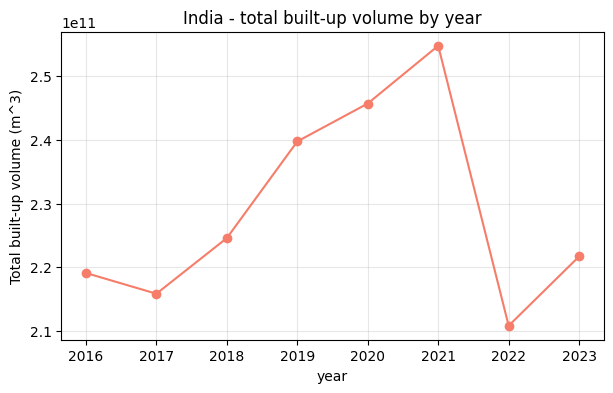

In [6]:
import matplotlib.pyplot as plt

national = df.groupby("year").volume_m3.sum()
ax = national.plot(marker="o", color="#f57d6a", figsize=(7, 4))
ax.set_ylabel("Total built-up volume (m^3)")
ax.set_title("India - total built-up volume by year")
ax.grid(alpha=0.3)
plt.show()

## 7 · Plot — choropleth, latest year

In [7]:
import plotly.express as px

latest = df.year.max()
sub = df[df.year == latest]

fig = px.choropleth(
    sub, geojson=gj, locations="pc11_d_id",
    featureidkey="properties.pc11_d_id",
    color="volume_m3", color_continuous_scale="OrRd",
    hover_name="d_name",
    labels={"volume_m3": "Built-up volume (m³)"},
)
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(title=f"Built-up volume by district — {latest}",
                   margin=dict(l=0, r=0, t=40, b=0))
fig.show()

## 8 · Plot — top 20 districts, latest year

In [8]:
top = sub.nlargest(20, "volume_m3").sort_values("volume_m3")
fig = px.bar(top, x="volume_m3", y="d_name", orientation="h",
             hover_data=["pc11_s_id"],
             labels={"volume_m3": "Built-up volume (m³)", "d_name": "District"},
             color_discrete_sequence=["#f57d6a"])
fig.update_layout(title=f"Top 20 districts by built-up volume — {latest}",
                  height=560, margin=dict(l=10, r=10, t=40, b=10))
fig.show()

## 9 · Download the result

In [9]:
try:
    from google.colab import files
    files.download(OUT_CSV)
except Exception:
    print("Not on Colab — file is at", OUT_CSV)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

> **Caveat.** This series is the *raw* Open Buildings 2.5D output — it has
> not been cleaned, and the **2022** snapshot in particular looks problematic.
> Treat it with caution.
